In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

df = pd.read_csv(r'IMDB Dataset.csv')

# Criando métricas de texto básicas
df['review_len'] = df['review'].astype(str).apply(len)
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

df.head()

,review,sentiment,review_len,word_count
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


/var/folders/8r/9lkd9b_s76n56hpgsm3jgm7c0000gn/T/ipykernel_50073/2999815043.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


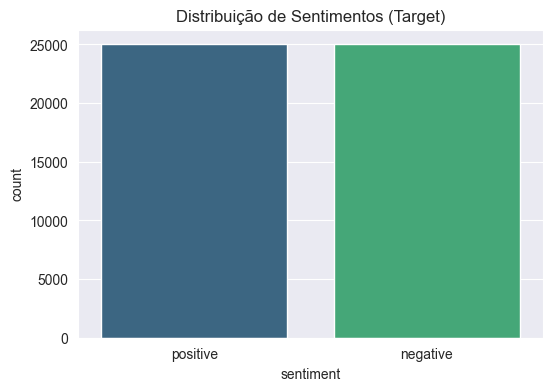

sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Distribuição de Sentimentos (Target)')
plt.show()

print(df['sentiment'].value_counts(normalize=True) * 100)

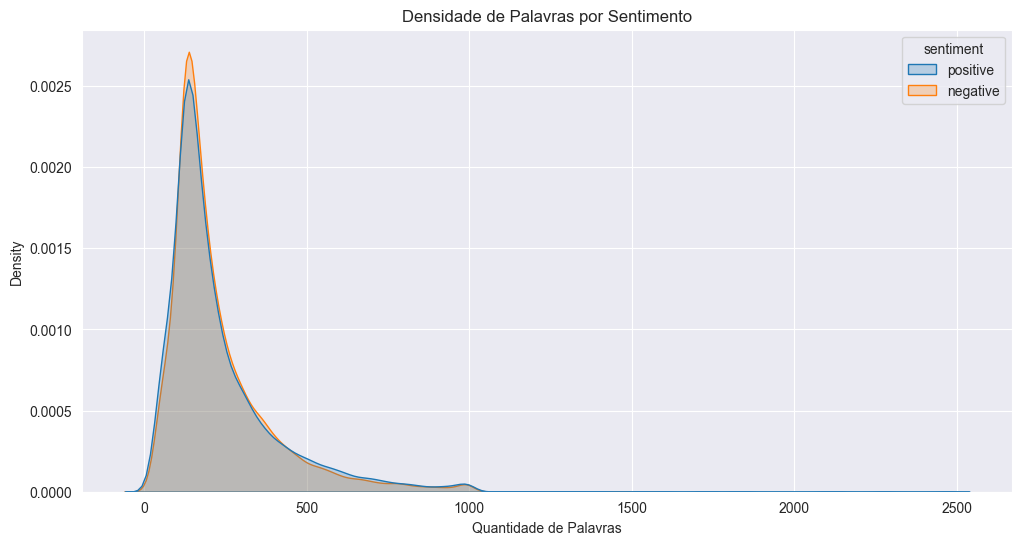

In [11]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='word_count', hue='sentiment', fill=True)
plt.title('Densidade de Palavras por Sentimento')
plt.xlabel('Quantidade de Palavras')
plt.show()

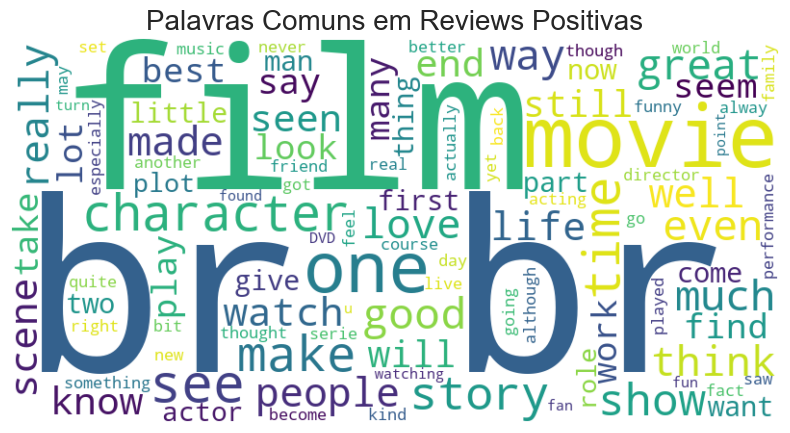

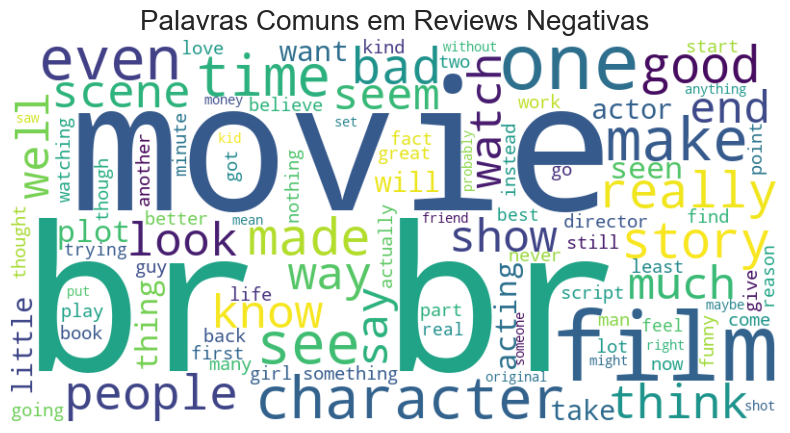

In [12]:
def plot_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

# Wordcloud para Positivos
pos_text = " ".join(df[df['sentiment'] == 'positive']['review'])
plot_wordcloud(pos_text, "Palavras Comuns em Reviews Positivas")

# Wordcloud para Negativos
neg_text = " ".join(df[df['sentiment'] == 'negative']['review'])
plot_wordcloud(neg_text, "Palavras Comuns em Reviews Negativas")